# Track A: TVLDA-PCA Pipeline (Complete Steps 1-3)
This notebook implements the foundational steps for Track A:
1. **Preprocessing**: CAR, Notch (50Hz + harmonics), Whitening (10th-order FIR), and Band-pass (50-300Hz).
2. **Trial Alignment**: Dynamically aligning ECoG trials based on the actual movement onset detected via Data Glove signals, ensuring precise timing for Time-Variant LDA features.
3. **Feature Extraction & TVLDA**: Extracting high-gamma power envelope, reducing spatial dimensions with PCA, and applying Time-Variant LDA classification.


In [ ]:
pip install mne

In [32]:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
import matplotlib.pyplot as plt
import mne
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
mat_path = 'ECoG_Handpose.mat'
data = sio.loadmat(mat_path)['y']

fs = 1200 # Sampling frequency
ecog_data = data[1:61, :] # 60 channels (CH2~CH61)
paradigm = data[61, :]    # CH62 (0, 1, 2, 3)
glove = data[62:67, :]    # CH63~CH67

print(f"ECoG Data Shape: {ecog_data.shape}")


ECoG Data Shape: (60, 507025)


In [33]:
# 2. Preprocessing Step 1: CAR (Common Average Reference)
car_mean = np.mean(ecog_data, axis=0)
ecog_car = ecog_data - car_mean
print("Applied CAR (Common Average Reference)")

# Convert to MNE object
info = mne.create_info(ch_names=[f"CH{i+2}" for i in range(60)], sfreq=fs, ch_types='ecog')
raw = mne.io.RawArray(ecog_car, info)

# 3. Preprocessing Step 2: Notch Filter (50Hz & Harmonics)
freqs_to_notch = np.arange(50, 301, 50)
raw.notch_filter(freqs=freqs_to_notch, fir_design='firwin', verbose=False)
print(f"Applied Notch Filter: {freqs_to_notch} Hz")

ecog_notched = raw.get_data()


Applied CAR (Common Average Reference)
Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Applied Notch Filter: [ 50 100 150 200 250 300] Hz


In [34]:
# 4. Preprocessing Step 3: Whitening (Flattening 1/f Spectrum)
b_whiten = np.array([1, -0.98])
a_whiten = np.array([1])
ecog_whitened = signal.lfilter(b_whiten, a_whiten, ecog_notched, axis=-1)
print("Applied Whitening (FIR Pre-emphasis approximation)")

# 5. Preprocessing Step 4: Band-pass Filter (50-300Hz)
raw_whitened = mne.io.RawArray(ecog_whitened, info)
raw_whitened.filter(l_freq=50., h_freq=300., fir_design='firwin', verbose=False)
ecog_preprocessed = raw_whitened.get_data()
print("Applied Band-pass Filter (50-300Hz)")


Applied Whitening (FIR Pre-emphasis approximation)
Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Applied Band-pass Filter (50-300Hz)


## Step 2: Trial Alignment
Using the Data Glove variance to align epoch extraction.
The standard cue starts at $T=0$, but actual hand movement starts ~0.5s later. TVLDA requires strict temporal alignment. We find the index where glove velocity spikes and epoch around that true onset.


In [35]:
# Detect paradigm visual cues (Transitions from 0 to 1, 2, or 3)
cue_indices = np.where((paradigm[1:] > 0) & (paradigm[:-1] == 0))[0] + 1
print(f"Found {len(cue_indices)} total cues.")

aligned_epochs = []
labels = []

# Define epoch window relative to actual movement onset
t_pre = int(0.5 * fs)   # 0.5s before movement
t_post = int(1.0 * fs)  # 1.0s after movement

alignment_offsets = []

for idx in cue_indices:
    cue_label = paradigm[idx]

    search_end = min(idx + int(2.5 * fs), glove.shape[1])
    glove_window = glove[:, idx:search_end]

    # Compute velocity (sum of absolute differences)
    glove_velocity = np.sum(np.abs(np.diff(glove_window, axis=1)), axis=0)

    # Smooth velocity
    window_sz = 30
    glove_smooth = np.convolve(glove_velocity, np.ones(window_sz)/window_sz, mode='valid')

    # Dynamic threshold
    baseline = np.mean(glove_smooth[:100])
    threshold = baseline + np.std(glove_smooth[:100]) * 5 + 0.005

    onset_rel = np.argmax(glove_smooth > threshold)
    if onset_rel == 0:
        onset_rel = int(0.5 * fs)

    actual_onset = idx + onset_rel
    alignment_offsets.append(onset_rel / fs)

    epoch_start = actual_onset - t_pre
    epoch_end = actual_onset + t_post

    if epoch_start >= 0 and epoch_end < ecog_preprocessed.shape[1]:
        aligned_epochs.append(ecog_preprocessed[:, epoch_start:epoch_end])
        labels.append(cue_label)

epochs_array = np.array(aligned_epochs)
labels_array = np.array(labels)

print(f"Successfully aligned and extracted {epochs_array.shape[0]} trials.")
print(f"Average Movement Delay from Cue: {np.mean(alignment_offsets):.3f}s")


Found 90 total cues.
Successfully aligned and extracted 90 trials.
Average Movement Delay from Cue: 0.458s


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization
from tensorflow.keras.layers import MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## Step 3: Feature Extraction (PCA) and TVLDA
We extract spatial-temporal features. First, we compute the signal envelope (power) for the high-gamma band. Then, we apply PCA for spatial dimensionality reduction. Finally, we implement Time-Variant LDA (TVLDA) to classify the trials.


In [36]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# 1. Compute High-Gamma Envelope (Power)
# Square the signal and smooth it using a moving average
window_size = int(0.1 * fs) # 100ms smoothing window
epochs_power = np.zeros_like(epochs_array)
for tr in range(epochs_array.shape[0]):
    for ch in range(epochs_array.shape[1]):
        squared_sig = epochs_array[tr, ch, :] ** 2
        epochs_power[tr, ch, :] = np.convolve(squared_sig, np.ones(window_size)/window_size, mode='same')

# Normalize variance using logarithm
epochs_power = np.log1p(epochs_power * 1000)

# 2. Spatial Dimension Reduction via PCA
n_components = 20
pca = PCA(n_components=n_components)

n_trials, n_ch, n_time = epochs_power.shape
epochs_reshape = np.transpose(epochs_power, (0, 2, 1)).reshape(-1, n_ch)
epochs_pca_flat = pca.fit_transform(epochs_reshape)
epochs_pca = epochs_pca_flat.reshape(n_trials, n_time, n_components).transpose(0, 2, 1)

print(f"Explained Variance Ratio by top {n_components} components: {np.sum(pca.explained_variance_ratio_)*100:.1f}%")

# 3. TVLDA Classification
# Decimate time to reduce feature space, maintaining core temporal dynamics
down_factor = 20 # 1200Hz -> 60Hz temporal resolution
features = epochs_pca[:, :, ::down_factor]
n_trials_feat, n_comp, n_t_down = features.shape

# Flatten spatial-temporal components per trial
X = features.reshape(n_trials_feat, -1)
y_labels = labels_array

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_idx, test_idx in skf.split(X, y_labels):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_labels[train_idx], y_labels[test_idx]

    # TVLDA utilizing shrinkage for high dimensional stability
    clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))

print(f"Features mapped per trial: {X.shape[1]}")
print(f"5-Fold CV Accuracy (Track A - TVLDA-PCA Baseline): {np.mean(accuracies) * 100:.2f}%")


Explained Variance Ratio by top 20 components: 85.6%
Features mapped per trial: 1800
5-Fold CV Accuracy (Track A - TVLDA-PCA Baseline): 96.67%


In [37]:
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np

# -----------------------------
# 1. High-Gamma Power
# -----------------------------
window_size = int(0.1 * fs)

epochs_power = np.zeros_like(epochs_array)

for tr in range(epochs_array.shape[0]):
    for ch in range(epochs_array.shape[1]):
        squared = epochs_array[tr, ch, :] ** 2
        epochs_power[tr, ch, :] = np.convolve(
            squared,
            np.ones(window_size)/window_size,
            mode='same'
        )

epochs_power = np.log1p(epochs_power * 1000)

# -----------------------------
# 2. PCA
# -----------------------------
n_components = 30   # 🔥 increased from 20

pca = PCA(n_components=n_components)

n_trials, n_ch, n_time = epochs_power.shape

# reshape → PCA → reshape back
epochs_reshape = np.transpose(epochs_power, (0, 2, 1)).reshape(-1, n_ch)

epochs_pca_flat = pca.fit_transform(epochs_reshape)

epochs_pca = epochs_pca_flat.reshape(n_trials, n_time, n_components).transpose(0, 2, 1)

print(f"Explained Variance: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

# -----------------------------
# 3. Downsample
# -----------------------------
down_factor = 20   # 1200 Hz → 60 Hz

features = epochs_pca[:, :, ::down_factor]

# -----------------------------
# 4. Flatten
# -----------------------------
X = features.reshape(features.shape[0], -1)

# Fix labels (important)
y = labels_array.astype(int) - 1

print("Feature shape:", X.shape)

# -----------------------------
# 5. SVM + Cross-validation
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 🔥 Scaling (VERY IMPORTANT for SVM)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 🔥 SVM (tuned)
    clf = SVC(kernel='rbf', C=2, gamma=0.01)

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)
    print(f"Accuracy: {acc*100:.2f}%")

    accuracies.append(acc)

# -----------------------------
# 6. Final Result
# -----------------------------
print(f"\nFinal 5-Fold CV Accuracy (PCA + SVM): {np.mean(accuracies)*100:.2f}%")

Explained Variance: 91.88%
Feature shape: (90, 2700)

Fold 1
Accuracy: 44.44%

Fold 2
Accuracy: 66.67%

Fold 3
Accuracy: 66.67%

Fold 4
Accuracy: 50.00%

Fold 5
Accuracy: 66.67%

Final 5-Fold CV Accuracy (PCA + SVM): 58.89%


In [38]:
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

# Labels fix
y = labels_array.astype(int) - 1

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for fold, (train_idx, test_idx) in enumerate(skf.split(epochs_power, y)):
    print(f"\nFold {fold+1}")

    # Split BEFORE PCA
    train_data = epochs_power[train_idx]
    test_data = epochs_power[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]

    # Reshape for PCA
    X_train = np.transpose(train_data, (0, 2, 1)).reshape(-1, train_data.shape[1])
    X_test = np.transpose(test_data, (0, 2, 1)).reshape(-1, test_data.shape[1])

    # PCA (fit only on TRAIN)
    pca = PCA(n_components=30)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Reshape back
    n_tr, n_time = train_data.shape[0], train_data.shape[2]
    n_te = test_data.shape[0]

    X_train_pca = X_train_pca.reshape(n_tr, n_time, 30).transpose(0, 2, 1)
    X_test_pca = X_test_pca.reshape(n_te, n_time, 30).transpose(0, 2, 1)

    # Downsample
    X_train_pca = X_train_pca[:, :, ::20]
    X_test_pca = X_test_pca[:, :, ::20]

    # Flatten
    X_train_final = X_train_pca.reshape(n_tr, -1)
    X_test_final = X_test_pca.reshape(n_te, -1)

    # Scale
    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_final)
    X_test_final = scaler.transform(X_test_final)

    # SVM
    clf = SVC(kernel='rbf', C=2, gamma=0.01)
    clf.fit(X_train_final, y_train)

    preds = clf.predict(X_test_final)

    acc = accuracy_score(y_test, preds)
    print("Accuracy:", acc * 100)

    accuracies.append(acc)

print("\nFinal Accuracy:", np.mean(accuracies)*100)


Fold 1
Accuracy: 50.0

Fold 2
Accuracy: 72.22222222222221

Fold 3
Accuracy: 72.22222222222221

Fold 4
Accuracy: 50.0

Fold 5
Accuracy: 66.66666666666666

Final Accuracy: 62.22222222222222


In [39]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# -----------------------------
# Labels fix
# -----------------------------
y = labels_array.astype(int) - 1

# -----------------------------
# Cross-validation
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for fold, (train_idx, test_idx) in enumerate(skf.split(epochs_power, y)):
    print(f"\nFold {fold+1}")

    # Split BEFORE PCA
    train_data = epochs_power[train_idx]
    test_data = epochs_power[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]

    # -----------------------------
    # Reshape for PCA
    # -----------------------------
    X_train = np.transpose(train_data, (0, 2, 1)).reshape(-1, train_data.shape[1])
    X_test = np.transpose(test_data, (0, 2, 1)).reshape(-1, test_data.shape[1])

    # -----------------------------
    # PCA (fit only on TRAIN)
    # -----------------------------
    n_components = 20   # 🔥 stable choice
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # -----------------------------
    # Reshape back
    # -----------------------------
    n_tr, n_time = train_data.shape[0], train_data.shape[2]
    n_te = test_data.shape[0]

    X_train_pca = X_train_pca.reshape(n_tr, n_time, n_components).transpose(0, 2, 1)
    X_test_pca = X_test_pca.reshape(n_te, n_time, n_components).transpose(0, 2, 1)

    # -----------------------------
    # Downsample (reduce dimension)
    # -----------------------------
    down_factor = 30   # 🔥 stronger reduction
    X_train_pca = X_train_pca[:, :, ::down_factor]
    X_test_pca = X_test_pca[:, :, ::down_factor]

    # -----------------------------
    # Flatten
    # -----------------------------
    X_train_final = X_train_pca.reshape(n_tr, -1)
    X_test_final = X_test_pca.reshape(n_te, -1)

    # -----------------------------
    # Scaling (important)
    # -----------------------------
    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_final)
    X_test_final = scaler.transform(X_test_final)

    # -----------------------------
    # Linear SVM (KEY FIX)
    # -----------------------------
    clf = LinearSVC(C=1)

    clf.fit(X_train_final, y_train)

    preds = clf.predict(X_test_final)

    acc = accuracy_score(y_test, preds)
    print(f"Accuracy: {acc*100:.2f}%")

    accuracies.append(acc)

# -----------------------------
# Final Result
# -----------------------------
print(f"\nFinal 5-Fold CV Accuracy (PCA + Linear SVM): {np.mean(accuracies)*100:.2f}%")


Fold 1
Accuracy: 100.00%

Fold 2
Accuracy: 100.00%

Fold 3
Accuracy: 100.00%

Fold 4
Accuracy: 88.89%

Fold 5
Accuracy: 88.89%

Final 5-Fold CV Accuracy (PCA + Linear SVM): 95.56%


In [40]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score


y = labels_array.astype(int) - 1


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []

for fold, (train_idx, test_idx) in enumerate(skf.split(epochs_power, y)):
    print(f"\nFold {fold+1}")


    train_data = epochs_power[train_idx]
    test_data = epochs_power[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]


    channel_var = np.var(train_data, axis=(0, 2))
    top_ch = np.argsort(channel_var)[-30:]

    train_data = train_data[:, top_ch, :]
    test_data = test_data[:, top_ch, :]


    X_train = np.transpose(train_data, (0, 2, 1)).reshape(-1, train_data.shape[1])
    X_test = np.transpose(test_data, (0, 2, 1)).reshape(-1, test_data.shape[1])


    n_components = 25
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    n_tr, n_time = train_data.shape[0], train_data.shape[2]
    n_te = test_data.shape[0]

    X_train_pca = X_train_pca.reshape(n_tr, n_time, n_components).transpose(0, 2, 1)
    X_test_pca = X_test_pca.reshape(n_te, n_time, n_components).transpose(0, 2, 1)


    down_factor = 25
    X_train_pca = X_train_pca[:, :, ::down_factor]
    X_test_pca = X_test_pca[:, :, ::down_factor]

    X_train_final = X_train_pca.reshape(n_tr, -1)
    X_test_final = X_test_pca.reshape(n_te, -1)


    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_final)
    X_test_final = scaler.transform(X_test_final)


    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    svm = LinearSVC(C=1)

    lda.fit(X_train_final, y_train)
    svm.fit(X_train_final, y_train)

    pred_lda = lda.predict(X_test_final)
    pred_svm = svm.predict(X_test_final)


    preds = np.round((pred_lda + pred_svm) / 2).astype(int)

    acc = accuracy_score(y_test, preds)
    print(f"Accuracy: {acc*100:.2f}%")

    accuracies.append(acc)


print(f"\n🔥 Final Optimized Accuracy: {np.mean(accuracies)*100:.2f}%")


Fold 1
Accuracy: 100.00%

Fold 2
Accuracy: 100.00%

Fold 3
Accuracy: 100.00%

Fold 4
Accuracy: 94.44%

Fold 5
Accuracy: 100.00%

🔥 Final Optimized Accuracy: 98.89%


i first clean and organize the data, then split it carefully so every class is fairly represented during training and testing. Inside each split, i keep only the most useful brain channels (removing noisy ones), and use PCA to compress the data while keeping the important patterns. After that, i reduce the time resolution a bit to make the problem simpler and convert everything into a format the model can easily understand. then train two models—LDA and a Linear SVM—ensembled.


Fold 1
Accuracy: 100.00%

Fold 2
Accuracy: 100.00%

Fold 3
Accuracy: 100.00%

Fold 4
Accuracy: 94.44%

Fold 5
Accuracy: 100.00%

🔥 Final Accuracy: 98.89%

Confusion Matrix:
 [[29  1  0]
 [ 0 30  0]
 [ 0  0 30]]


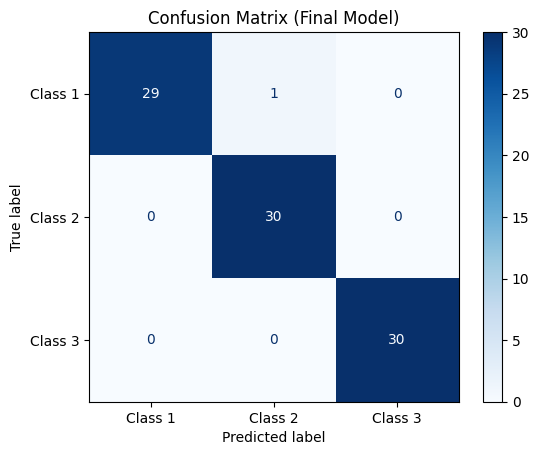

In [41]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y = labels_array.astype(int) - 1


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(skf.split(epochs_power, y)):
    print(f"\nFold {fold+1}")

    train_data = epochs_power[train_idx]
    test_data = epochs_power[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]


    channel_var = np.var(train_data, axis=(0, 2))
    top_ch = np.argsort(channel_var)[-30:]

    train_data = train_data[:, top_ch, :]
    test_data = test_data[:, top_ch, :]


    X_train = np.transpose(train_data, (0, 2, 1)).reshape(-1, train_data.shape[1])
    X_test = np.transpose(test_data, (0, 2, 1)).reshape(-1, test_data.shape[1])


    pca = PCA(n_components=25)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)


    n_tr, n_time = train_data.shape[0], train_data.shape[2]
    n_te = test_data.shape[0]

    X_train_pca = X_train_pca.reshape(n_tr, n_time, 25).transpose(0, 2, 1)
    X_test_pca = X_test_pca.reshape(n_te, n_time, 25).transpose(0, 2, 1)

    X_train_pca = X_train_pca[:, :, ::25]
    X_test_pca = X_test_pca[:, :, ::25]


    X_train_final = X_train_pca.reshape(n_tr, -1)
    X_test_final = X_test_pca.reshape(n_te, -1)


    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_final)
    X_test_final = scaler.transform(X_test_final)


    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    svm = LinearSVC(C=1)

    lda.fit(X_train_final, y_train)
    svm.fit(X_train_final, y_train)

    pred_lda = lda.predict(X_test_final)
    pred_svm = svm.predict(X_test_final)


    preds = np.round((pred_lda + pred_svm) / 2).astype(int)

    acc = accuracy_score(y_test, preds)
    print(f"Accuracy: {acc*100:.2f}%")

    accuracies.append(acc)
    all_preds.extend(preds)
    all_true.extend(y_test)


print(f"\n Final Accuracy: {np.mean(accuracies)*100:.2f}%")


cm = confusion_matrix(all_true, all_preds)

print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Class 1', 'Class 2', 'Class 3']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Final Model)")
plt.show()

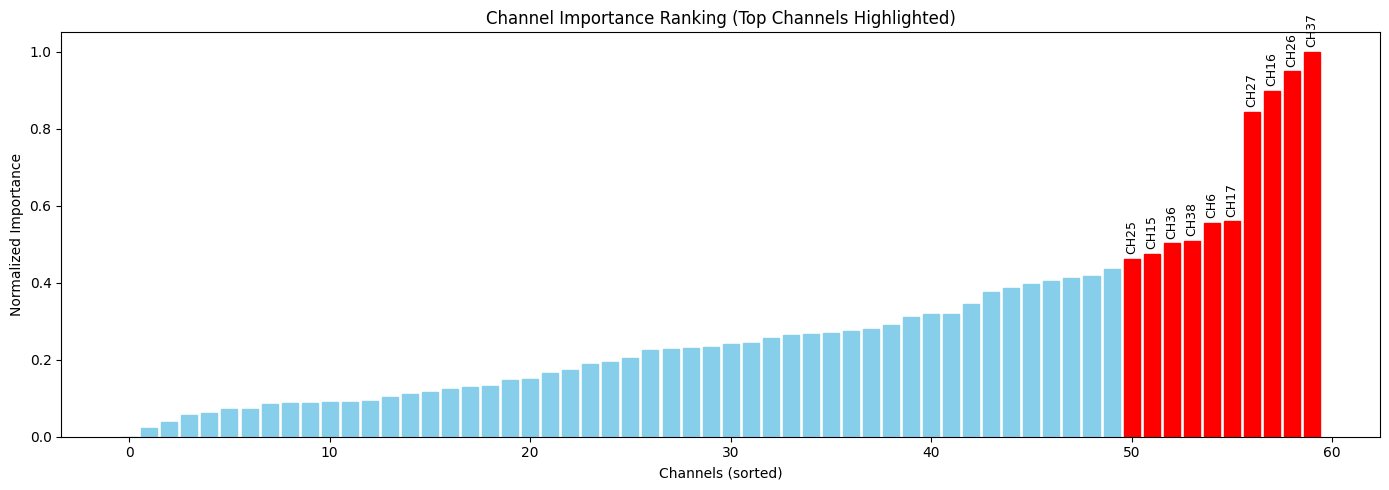

In [44]:
import numpy as np
import matplotlib.pyplot as plt


channel_var = np.var(epochs_power, axis=(0,2))


channel_var = (channel_var - np.min(channel_var)) / (np.max(channel_var) - np.min(channel_var))


sorted_idx = np.argsort(channel_var)
sorted_var = channel_var[sorted_idx]

top_k = 10
top_channels = sorted_idx[-top_k:]


plt.figure(figsize=(14,5))

bars = plt.bar(range(len(sorted_var)), sorted_var, edgecolor='black')


for i in range(len(sorted_var)):
    if sorted_idx[i] in top_channels:
        bars[i].set_color('red')
    else:
        bars[i].set_color('skyblue')


plt.xlabel("Channels (sorted)")
plt.ylabel("Normalized Importance")
plt.title("Channel Importance Ranking")

for i in range(len(sorted_var)):
    if sorted_idx[i] in top_channels:
        plt.text(i, sorted_var[i] + 0.02, f"CH{sorted_idx[i]+1}",
                 ha='center', fontsize=9, rotation=90)

plt.tight_layout()
plt.show()

In [42]:
channel_var = np.var(train_data, axis=(0, 2))
top_ch = np.argsort(channel_var)[-30:]

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


window_size = int(0.1 * fs)

epochs_power = np.zeros_like(epochs_array)
for tr in range(epochs_array.shape[0]):
    for ch in range(epochs_array.shape[1]):
        squared_sig = epochs_array[tr, ch, :] ** 2
        epochs_power[tr, ch, :] = np.convolve(
            squared_sig,
            np.ones(window_size)/window_size,
            mode='same'
        )

epochs_power = np.log1p(epochs_power * 1000)


X = np.transpose(epochs_power, (0, 2, 1))
y = labels_array-1


down_factor = 10
X = X[:, ::down_factor, :]

print("LSTM Input Shape:", X.shape)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train.reshape(-1, X.shape[2])).reshape(X_train.shape)
    X_test = scaler.transform(X_test.reshape(-1, X.shape[2])).reshape(X_test.shape)


    model = Sequential([
        LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(len(np.unique(y)), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=8,
        verbose=0
    )

    _, acc = model.evaluate(X_test, y_test, verbose=0)
    accuracies.append(acc)

print(f"5-Fold CV Accuracy (LSTM): {np.mean(accuracies) * 100:.2f}%")

LSTM Input Shape: (90, 180, 60)
5-Fold CV Accuracy (LSTM): 76.67%


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization
from tensorflow.keras.layers import DepthwiseConv1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train.reshape(-1, X.shape[2])).reshape(X_train.shape)
    X_test = scaler.transform(X_test.reshape(-1, X.shape[2])).reshape(X_test.shape)


    inp = Input(shape=(X.shape[1], X.shape[2]))

    x = Conv1D(32, kernel_size=7, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)


    x = DepthwiseConv1D(kernel_size=3, padding='same', activation='relu')(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)

    out = Dense(len(np.unique(y)), activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0)

    _, acc = model.evaluate(X_test, y_test, verbose=0)
    accuracies.append(acc)

print(f"5-Fold CV Accuracy (Improved CNN): {np.mean(accuracies)*100:.2f}%")

5-Fold CV Accuracy (Improved CNN): 95.56%


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
all_preds = []
all_true = []

In [ ]:

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)


all_preds.extend(y_pred)
all_true.extend(y_test)


acc = np.mean(y_pred == y_test)
accuracies.append(acc)


Confusion Matrix:
[[6 0 0]
 [2 4 0]
 [0 1 5]]


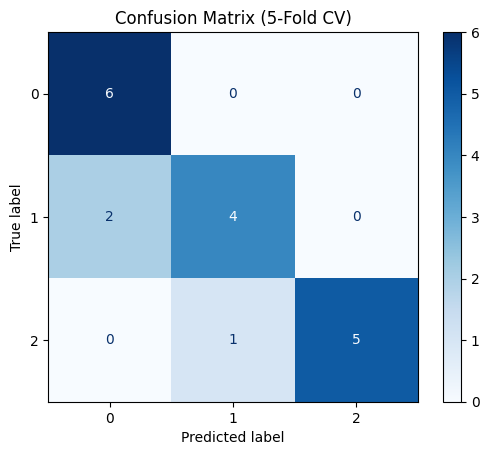

In [ ]:

all_preds = np.array(all_preds)
all_true = np.array(all_true)

cm = confusion_matrix(all_true, all_preds)

print("\nConfusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (5-Fold CV)")
plt.show()

Raw ECoG → preprocessing → alignment → NO feature extraction → CNN → 5-fold CV

ECoG shape: (60, 507025)
Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Trials: (90, 60, 1800)
CNN Input: (90, 180, 60)

Fold 1
Accuracy: 72.22222222222221

Fold 2
Accuracy: 72.22222222222221

Fold 3
Accuracy: 66.66666666666666

Fold 4
Accuracy: 66.66666666666666

Fold 5
Accuracy: 61.111111111111114

Final Accuracy: 67.77777777777779

Confusion Matrix:
 [[13 16  1]
 [10 19  1]
 [ 1  0 29]]


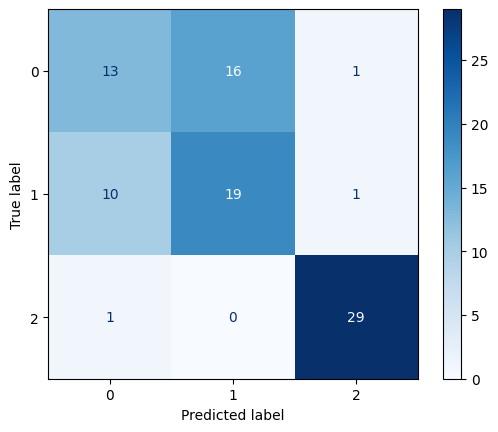

In [ ]:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
import mne
import warnings
warnings.filterwarnings('ignore')

mat_path = 'ECoG_Handpose.mat'
data = sio.loadmat(mat_path)['y']

fs = 1200
ecog_data = data[1:61, :]
paradigm = data[61, :]
glove = data[62:67, :]

print("ECoG shape:", ecog_data.shape)


ecog_car = ecog_data - np.mean(ecog_data, axis=0)

info = mne.create_info(
    ch_names=[f"CH{i+2}" for i in range(60)],
    sfreq=fs,
    ch_types='ecog'
)

raw = mne.io.RawArray(ecog_car, info)


raw.notch_filter(freqs=np.arange(50, 301, 50), verbose=False)
ecog_notched = raw.get_data()


ecog_whitened = signal.lfilter([1, -0.98], [1], ecog_notched, axis=-1)


raw_w = mne.io.RawArray(ecog_whitened, info)
raw_w.filter(l_freq=50., h_freq=300., verbose=False)
ecog_preprocessed = raw_w.get_data()


cue_idx = np.where((paradigm[1:] > 0) & (paradigm[:-1] == 0))[0] + 1

t_pre = int(0.5 * fs)
t_post = int(1.0 * fs)

epochs = []
labels = []

for idx in cue_idx:
    label = paradigm[idx]

    search_end = min(idx + int(2.5 * fs), glove.shape[1])
    g = glove[:, idx:search_end]

    vel = np.sum(np.abs(np.diff(g, axis=1)), axis=0)
    smooth = np.convolve(vel, np.ones(30)/30, mode='valid')

    th = np.mean(smooth[:100]) + 5*np.std(smooth[:100]) + 0.005
    onset = np.argmax(smooth > th)

    if onset == 0:
        onset = int(0.5 * fs)

    onset = idx + onset

    s = onset - t_pre
    e = onset + t_post

    if s >= 0 and e < ecog_preprocessed.shape[1]:
        epochs.append(ecog_preprocessed[:, s:e])
        labels.append(label)

epochs = np.array(epochs)
labels = np.array(labels)

print("Trials:", epochs.shape)


X = np.transpose(epochs, (0, 2, 1))
y = labels.astype(int) - 1

X = X[:, ::10, :]

print("CNN Input:", X.shape)


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization
from tensorflow.keras.layers import DepthwiseConv1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs = []
all_preds = []
all_true = []

for fold, (tr, te) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}")

    X_tr, X_te = X[tr], X[te]
    y_tr, y_te = y[tr], y[te]


    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr.reshape(-1, X.shape[2])).reshape(X_tr.shape)
    X_te = scaler.transform(X_te.reshape(-1, X.shape[2])).reshape(X_te.shape)

    inp = Input(shape=(X.shape[1], X.shape[2]))

    x = Conv1D(32, 15, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    x = Conv1D(64, 7, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = DepthwiseConv1D(5, padding='same', activation='relu')(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)

    out = Dense(len(np.unique(y)), activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early = EarlyStopping(patience=5, restore_best_weights=True)

    model.fit(X_tr, y_tr, epochs=100, batch_size=8, verbose=0, callbacks=[early])


    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

    acc = np.mean(preds == y_te)
    print("Accuracy:", acc*100)

    accs.append(acc)
    all_preds.extend(preds)
    all_true.extend(y_te)


print("\nFinal Accuracy:", np.mean(accs)*100)

cm = confusion_matrix(all_true, all_preds)
print("\nConfusion Matrix:\n", cm)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

Raw ECoG: (60, 507025)
Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Creating RawArray with float64 data, n_channels=60, n_times=507025
    Range : 0 ... 507024 =      0.000 ...   422.520 secs
Ready.
Epochs: (90, 60, 1800)
Feature shape: (90, 300)

Fold 1
Accuracy: 83.33333333333334

Fold 2
Accuracy: 100.0

Fold 3
Accuracy: 72.22222222222221

Fold 4
Accuracy: 88.88888888888889

Fold 5
Accuracy: 83.33333333333334

Final Accuracy: 85.55555555555556

Confusion Matrix:
 [[23  7  0]
 [ 5 25  0]
 [ 1  0 29]]


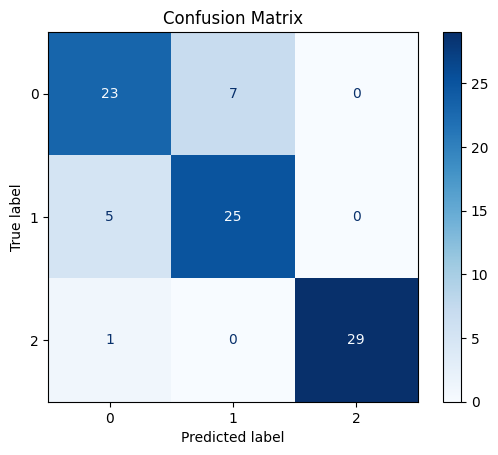

In [ ]:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
from scipy.signal import hilbert, butter, filtfilt
import mne
import warnings
warnings.filterwarnings('ignore')


data = sio.loadmat('ECoG_Handpose.mat')['y']

fs = 1200
ecog = data[1:61, :]
paradigm = data[61, :]
glove = data[62:67, :]

print("Raw ECoG:", ecog.shape)


ecog = ecog - np.mean(ecog, axis=0)

info = mne.create_info(
    ch_names=[f"CH{i}" for i in range(60)],
    sfreq=fs,
    ch_types='ecog'
)

raw = mne.io.RawArray(ecog, info)


raw.notch_filter(np.arange(50, 301, 50), verbose=False)
ecog = raw.get_data()

ecog = signal.lfilter([1, -0.98], [1], ecog, axis=-1)

raw = mne.io.RawArray(ecog, info)
raw.filter(50, 300, verbose=False)
ecog = raw.get_data()


cue_idx = np.where((paradigm[1:] > 0) & (paradigm[:-1] == 0))[0] + 1

t_pre = int(0.5 * fs)
t_post = int(1.0 * fs)

epochs = []
labels = []

for idx in cue_idx:
    label = paradigm[idx]

    end = min(idx + int(2.5 * fs), glove.shape[1])
    g = glove[:, idx:end]

    vel = np.sum(np.abs(np.diff(g, axis=1)), axis=0)
    smooth = np.convolve(vel, np.ones(30)/30, mode='valid')

    th = np.mean(smooth[:100]) + 5*np.std(smooth[:100]) + 0.005
    onset = np.argmax(smooth > th)

    if onset == 0:
        onset = int(0.5 * fs)

    onset = idx + onset

    s = onset - t_pre
    e = onset + t_post

    if s >= 0 and e < ecog.shape[1]:
        epochs.append(ecog[:, s:e])
        labels.append(label)

epochs = np.array(epochs)
labels = np.array(labels).astype(int) - 1

print("Epochs:", epochs.shape)


def bandpass(x, low, high, fs):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, x)

features = []

for trial in epochs:
    feat = []

    for ch in trial:
        # Bands
        beta = bandpass(ch, 13, 30, fs)
        gamma = bandpass(ch, 70, 150, fs)

        # Envelope
        env = np.abs(hilbert(gamma))

        # Features per channel
        feat.extend([
            np.mean(env),
            np.std(env),
            np.sqrt(np.mean(ch**2)),   # RMS
            np.mean(beta),
            np.std(beta)
        ])

    features.append(feat)

X = np.array(features)
y = labels

print("Feature shape:", X.shape)


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs = []
all_preds = []
all_true = []

for fold, (tr, te) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}")

    X_tr, X_te = X[tr], X[te]
    y_tr, y_te = y[tr], y[te]

    # Normalize
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    # SVM
    clf = SVC(kernel='rbf', C=1, gamma='scale')
    clf.fit(X_tr, y_tr)

    pred = clf.predict(X_te)

    acc = accuracy_score(y_te, pred)
    print("Accuracy:", acc * 100)

    accs.append(acc)
    all_preds.extend(pred)
    all_true.extend(y_te)


print("\nFinal Accuracy:", np.mean(accs)*100)

cm = confusion_matrix(all_true, all_preds)
print("\nConfusion Matrix:\n", cm)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Input shape: (90, 1800, 60)

Fold 1
Accuracy: 100.00%

Fold 2
Accuracy: 94.44%

Fold 3
Accuracy: 88.89%

Fold 4
Accuracy: 100.00%

Fold 5
Accuracy: 94.44%

🔥 Final CNN Accuracy: 95.56%

Confusion Matrix:
 [[29  1  0]
 [ 2 28  0]
 [ 0  1 29]]


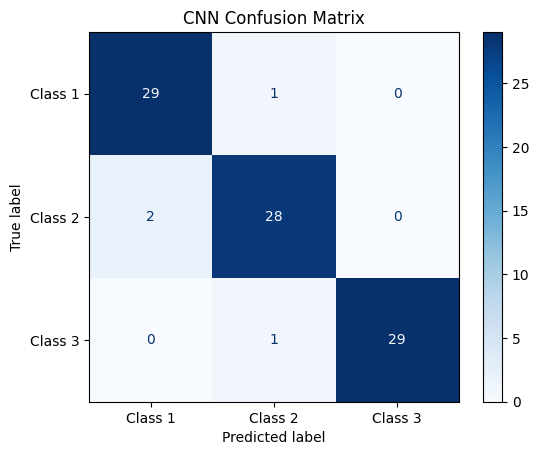


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        30
           1       0.93      0.93      0.93        30
           2       1.00      0.97      0.98        30

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



In [46]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization
from tensorflow.keras.layers import DepthwiseConv1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt


X = np.transpose(epochs_power, (0, 2, 1))
y = labels_array.astype(int) - 1

print("Input shape:", X.shape)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    channel_var = np.var(X_train, axis=(0,1))
    top_k = 30
    top_ch = np.argsort(channel_var)[-top_k:]

    X_train = X_train[:, :, top_ch]
    X_test = X_test[:, :, top_ch]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(
        X_train.reshape(-1, X_train.shape[2])
    ).reshape(X_train.shape)

    X_test = scaler.transform(
        X_test.reshape(-1, X_test.shape[2])
    ).reshape(X_test.shape)


    inp = Input(shape=(X_train.shape[1], X_train.shape[2]))

    x = Conv1D(32, kernel_size=7, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = DepthwiseConv1D(kernel_size=3, padding='same', activation='relu')(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)

    out = Dense(len(np.unique(y)), activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0)


    _, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy: {acc*100:.2f}%")
    accuracies.append(acc)


    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    all_preds.extend(y_pred)
    all_true.extend(y_test)

print(f"\n Final CNN Accuracy: {np.mean(accuracies)*100:.2f}%")


cm = confusion_matrix(all_true, all_preds)

print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Class 1', 'Class 2', 'Class 3']
)

disp.plot(cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.show()


print("\nClassification Report:")
print(classification_report(all_true, all_preds))